# Лабораторна робота № 2 — моделювання лінійних систем

Варіант 3. Вовкотруб Олександр Віталійович, група ФБ-61мн.
КПІ ім. Ігоря Сікорського, ННФТІ, кафедра інформаційної безпеки.

Передатна функція варіанта, стійкість, часові та частотні характеристики,
канонічні форми в просторі станів.
Зведення обчислених величин наприкінці вивантажується у `data/results-summary.csv`.

## 0. Підготовка середовища

Клітинка нижче створює теки `assets/` і `data/` поруч із ноутбуком і, якщо
якоїсь бібліотеки бракує, доставляє її. Завдяки цьому ноутбук виконується
як локально, так і в Colab без жодних ручних кроків.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path


def _in_colab() -> bool:
    if "google.colab" in sys.modules:
        return True
    try:
        return importlib.util.find_spec("google.colab") is not None
    except (ImportError, ValueError):
        # find_spec імпортує батьківський пакет; без нього це не Colab
        return False


IN_COLAB = _in_colab()

REQUIRED = ['numpy', 'scipy', 'sympy', 'matplotlib']
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

ASSETS = Path("assets")
DATA = Path("data")
ASSETS.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

ASSETS = Path("assets")
DATA = Path("data")
ASSETS.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "DejaVu Serif"],
    "font.size": 11,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def save(fig, name) -> None:
    """Зберегти рисунок у assets/ і показати його в ноутбуці."""
    fig.savefig(ASSETS / name)
    try:
        from IPython.display import display
        display(fig)   # інакше рисунка не буде ні в .ipynb, ні в Colab
    except ImportError:
        pass
    plt.close(fig)


RESULTS: list[dict] = []


def record(section: str, name: str, value, note: str = "") -> None:
    """Запам'ятати число для `data/results-summary.csv` і показати його."""
    RESULTS.append({"розділ": section, "показник": name, "значення": value, "примітка": note})
    print(f"{section} | {name} = {value}  {note}")

## 1. Передатна функція за варіантом 3

$$G(p) = \frac{p^{2} - 7p + 3}{11p^{4} + 5p + 1}$$

Переходимо до zpk-форми функцією `scipy.signal.tf2zpk`, як вимагає умова.

ПФ варіанта | нулі = [(0.4586+0j), (6.5414+0j)]  
ПФ варіанта | полюси = [(-0.6853+0j), (-0.2038+0j), (0.4446-0.6732j), (0.4446+0.6732j)]  
ПФ варіанта | коефіцієнт підсилення k = 0.090909  = 1/11
ПФ варіанта | полюсів з Re>0 = 2  
ПФ варіанта | нулів з Re>0 = 2  система немінімально-фазова


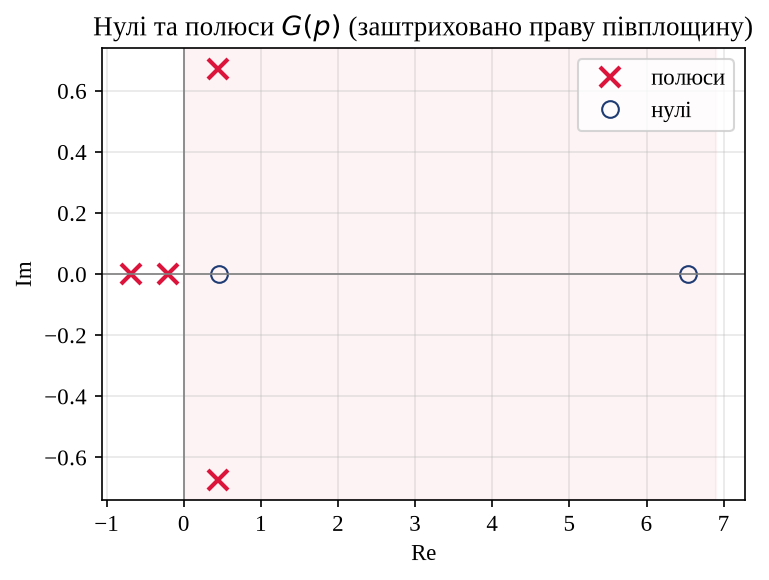

In [3]:
NUM = [1, -7, 3]          # p^2 - 7p + 3
DEN = [11, 0, 0, 5, 1]    # 11p^4 + 5p + 1

zeros, poles, gain = signal.tf2zpk(NUM, DEN)
record("ПФ варіанта", "нулі", np.round(np.sort_complex(zeros), 4).tolist())
record("ПФ варіанта", "полюси", np.round(np.sort_complex(poles), 4).tolist())
record("ПФ варіанта", "коефіцієнт підсилення k", f"{gain:.6f}", "= 1/11")
record("ПФ варіанта", "полюсів з Re>0", int((poles.real > 0).sum()))
record("ПФ варіанта", "нулів з Re>0", int((zeros.real > 0).sum()),
       "система немінімально-фазова")

assert int((poles.real > 0).sum()) == 2
assert int((zeros.real > 0).sum()) == 2
assert abs(gain - 1 / 11) < 1e-12

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.plot(poles.real, poles.imag, "x", ms=10, mew=2, color="crimson", label="полюси")
ax.plot(zeros.real, zeros.imag, "o", ms=8, mfc="none", color="#1f3b73", label="нулі")
ax.axvline(0, color="gray", lw=0.8); ax.axhline(0, color="gray", lw=0.8)
ax.axvspan(0, ax.get_xlim()[1], color="crimson", alpha=0.05)
ax.set_xlabel("Re"); ax.set_ylabel("Im")
ax.set_title("Нулі та полюси $G(p)$ (заштриховано праву півплощину)")
ax.legend()
fig.tight_layout(); save(fig, "01-poles-zeros.png")

Два полюси ($0.4446 \pm 0.6732j$) лежать у правій півплощині — система
нестійка. Два нулі ($0.4586$ і $6.5414$) також у правій півплощині — це
додатково означає, що система немінімально-фазова.

## 2. Чи можна застабілізувати цю систему підсиленням $k_u$?

Умова пропонує замкнути систему одиничним від'ємним зворотним зв'язком і
**підшукати $k_u$**. Замкнена передатна функція
$H(p) = \dfrac{k_u G(p)}{1 + k_u G(p)}$ має характеристичний поліном
$\mathrm{DEN}(p) + k_u \cdot \mathrm{NUM}(p)$:

$$11p^{4} + 0 \cdot p^{3} + k_u p^{2} + (5 - 7k_u)p + (1 + 3k_u)$$

Коефіцієнт при $p^3$ дорівнює нулю **тотожно за будь-якого $k_u$**: у
$\mathrm{DEN}(p) = 11p^4 + 5p + 1$ доданка з $p^3$ немає, і в
$\mathrm{NUM}(p) = p^2 - 7p + 3$ його теж немає (найвищий степінь чисельника
— другий), тож множення на $k_u$ й додавання коефіцієнтів при $p^3$ не може
його породити ні за якого значення $k_u$. Необхідна умова Гурвіца (усі
коефіцієнти одного знаку й ненульові) порушується для всіх $k_u$, тож
**жодне пропорційне підсилення систему не стабілізує**.

In [4]:
def closed_loop_denominator(ku: float) -> np.ndarray:
    """Характеристичний поліном замкненої системи з одиничним від'ємним ЗЗ."""
    return np.polyadd(DEN, np.polymul([ku], NUM))


rows = []
for ku in [0.1, 0.5, 1, 2, 5, 10, 50]:
    r = np.roots(closed_loop_denominator(ku))
    rows.append((ku, r.real.max(), bool((r.real < 0).all())))
    record("Стабілізація", f"max Re полюсів при ku={ku}", f"{r.real.max():.4f}",
           "стійка" if (r.real < 0).all() else "нестійка")

assert all(not stable for _, _, stable in rows), "несподівано знайшлося стійке ku"
# a3 дорівнює нулю для будь-якого ku — перевіряємо символьно
a3 = [closed_loop_denominator(ku)[1] for ku in (0.0, 1.0, 7.5, -3.0)]
assert all(abs(v) < 1e-12 for v in a3), a3
record("Стабілізація", "коефіцієнт при p^3 замкненої системи", 0,
       "тотожно нуль -> необхідна умова Гурвіца не виконується за жодного ku")

Стабілізація | max Re полюсів при ku=0.1 = 0.4486  нестійка
Стабілізація | max Re полюсів при ku=0.5 = 0.4792  нестійка
Стабілізація | max Re полюсів при ku=1 = 0.5309  нестійка
Стабілізація | max Re полюсів при ku=2 = 0.6213  нестійка
Стабілізація | max Re полюсів при ku=5 = 0.8718  нестійка
Стабілізація | max Re полюсів при ku=10 = 1.3769  нестійка
Стабілізація | max Re полюсів при ku=50 = 2.4460  нестійка
Стабілізація | коефіцієнт при p^3 замкненої системи = 0  тотожно нуль -> необхідна умова Гурвіца не виконується за жодного ku


## 3. Кореневий годограф як ілюстрація

Стежимо за коренями характеристичного полінома при зростанні $k_u$ від 0
до 60. Якщо серед них не з'явиться жодного зі стійким (лівим) розміщенням
для всіх чотирьох гілок одночасно, це підтверджує висновок пункту 2 графічно.

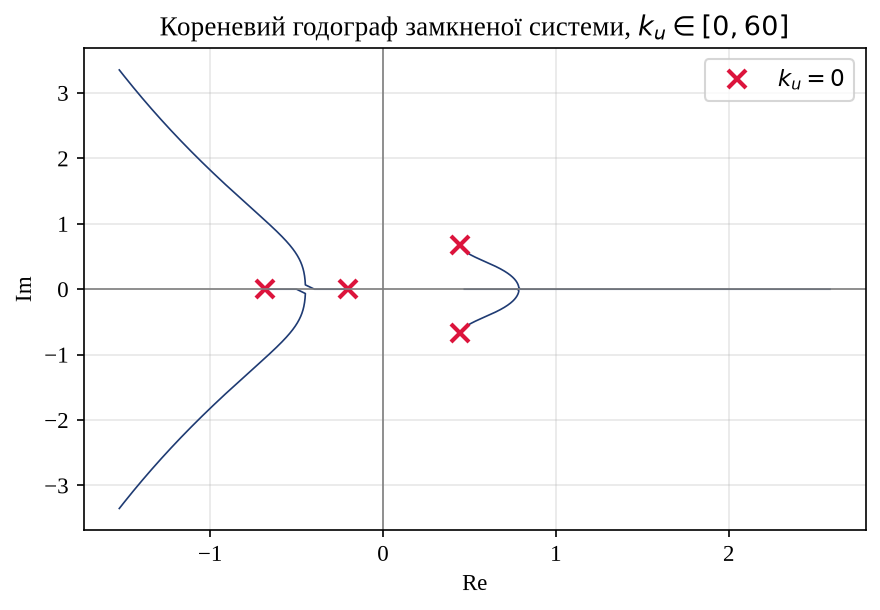

In [5]:
ku_grid = np.linspace(0, 60, 4000)
branches = np.array([np.sort_complex(np.roots(closed_loop_denominator(k))) for k in ku_grid])

fig, ax = plt.subplots(figsize=(6.0, 4.2))
for j in range(branches.shape[1]):
    ax.plot(branches[:, j].real, branches[:, j].imag, lw=0.8, color="#1f3b73")
ax.plot(poles.real, poles.imag, "x", ms=9, mew=2, color="crimson", label="$k_u = 0$")
ax.axvline(0, color="gray", lw=0.8); ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Re"); ax.set_ylabel("Im")
ax.set_title(r"Кореневий годограф замкненої системи, $k_u \in [0, 60]$")
ax.legend()
fig.tight_layout(); save(fig, "02-root-locus.png")

На рисунку жодна гілка не переходить у ліву півплощину — саме це й
доводиться: пропорційне підсилення $k_u$ не може перемістити всі полюси
замкненої системи в область $\mathrm{Re}\,p < 0$.

## 4. Чи рятує ПД-регулятор?

Природне питання: а якщо додати похідну, тобто взяти $C(p) = k_u(T_d p + 1)$ —
це дає ненульовий коефіцієнт при $p^3$ (він дорівнює $k_u T_d$ — коефіцієнту
при $p^2$ чисельника, помноженому на похідну складову). Перебираємо сітку
$k_u \in (0, 20]$, $T_d \in (0, 20]$ з кроком 0.05 (400x400 точок) і шукаємо
мінімум $\max \mathrm{Re}$ коренів по всій сітці.

In [6]:
best = None
for ku in np.arange(0.05, 20.01, 0.05):
    for td in np.arange(0.01, 20.01, 0.05):
        ch = np.polyadd(DEN, np.polymul([ku * td, ku], NUM))
        m = np.roots(ch).real.max()
        if best is None or m < best[0]:
            best = (m, ku, td)
record("Стабілізація", "ПД-регулятор: найкраще max Re", f"{best[0]:.4f}",
       f"при ku={best[1]:.2f}, Td={best[2]:.2f} — усе одно > 0")
assert best[0] > 0, "ПД несподівано застабілізував — перевірити висновки звіту"

Стабілізація | ПД-регулятор: найкраще max Re = 0.4464  при ku=0.05, Td=0.01 — усе одно > 0


Навіть найкраща точка сітки 400x400 (крок 0.05 по обох параметрах на
$(0, 20]$) залишає $\max \mathrm{Re} > 0$ — ПД-регулятор теж не стабілізує
цю систему пропорційно-диференціальним законом керування з перебраного
діапазону параметрів.

## 5. Стійка система за схемою Рис.5

Оскільки власну $G(p)$ підсиленням застабілізувати неможливо (доведено вище),
далі працюємо зі слідкуючою системою зі схеми Рис.5 умови:
розімкнена ланка $k_u \dfrac{0.5}{s(s+2)}$, зворотний зв'язок одиничний від'ємний.

$$W(s) = \frac{0.5 k_u}{s^2 + 2s + 0.5 k_u}$$

Це стандартна ланка II порядку: $\omega_n = \sqrt{0.5k_u}$, $2\zeta\omega_n = 2$.
Беремо $k_u = 4$ — тоді $\zeta = 1/\sqrt{2} \approx 0.707$, класичне значення
на межі появи резонансу.

In [7]:
KU = 4.0
W_NUM = [0.5 * KU]
W_DEN = [1.0, 2.0, 0.5 * KU]
SYS = signal.TransferFunction(W_NUM, W_DEN)

WN = float(np.sqrt(0.5 * KU))
ZETA = float(2 / (2 * WN))
cl_poles = np.roots(W_DEN)

record("Стійка система", "ku", KU)
record("Стійка система", "W(s)", "2/(s^2 + 2s + 2)")
record("Стійка система", "полюси", np.round(np.sort_complex(cl_poles), 4).tolist())
record("Стійка система", "власна частота wn", f"{WN:.4f}")
record("Стійка система", "коефіцієнт загасання zeta", f"{ZETA:.4f}")
record("Стійка система", "статичний коефіцієнт підсилення W(0)", W_NUM[0] / W_DEN[-1])

assert (cl_poles.real < 0).all()
assert abs(ZETA - 1 / np.sqrt(2)) < 1e-12

Стійка система | ku = 4.0  
Стійка система | W(s) = 2/(s^2 + 2s + 2)  
Стійка система | полюси = [(-1-1j), (-1+1j)]  
Стійка система | власна частота wn = 1.4142  
Стійка система | коефіцієнт загасання zeta = 0.7071  
Стійка система | статичний коефіцієнт підсилення W(0) = 1.0  


### Імпульсна характеристика та перехідна функція

Показники якості знімаємо з перехідної функції **виміром** і порівнюємо
з теоретичними формулами — це перевірка, що модель правильна.

Часові характеристики | перерегулювання, % — вимір = 4.322  
Часові характеристики | перерегулювання, % — теорія = 4.321  
Часові характеристики | час усталення (2%), с — вимір = 4.216  
Часові характеристики | час усталення (2%), с — теорія = 4.000  
Часові характеристики | час наростання (до 100%), с = 2.356  


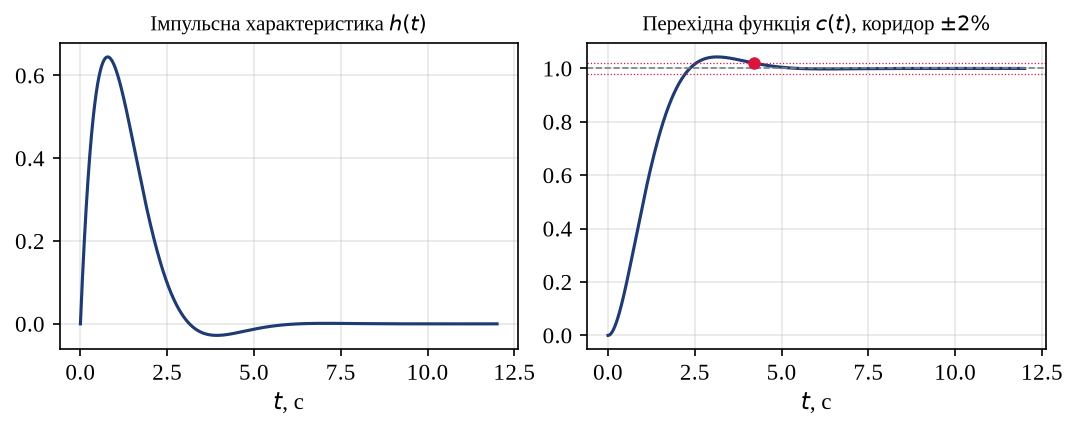

In [8]:
t = np.linspace(0, 12, 20001)
_, h = signal.impulse(SYS, T=t)
_, c = signal.step(SYS, T=t)

overshoot_measured = (c.max() - c[-1]) / c[-1] * 100
overshoot_theory = float(np.exp(-np.pi * ZETA / np.sqrt(1 - ZETA**2)) * 100)
outside = np.where(np.abs(c - 1) > 0.02)[0]
ts_measured = float(t[outside[-1]])
ts_theory = 4 / (ZETA * WN)
rise = float(t[np.argmax(c >= 1.0)])

for name, meas, theo in [
    ("перерегулювання, %", overshoot_measured, overshoot_theory),
    ("час усталення (2%), с", ts_measured, ts_theory),
]:
    record("Часові характеристики", f"{name} — вимір", f"{meas:.3f}")
    record("Часові характеристики", f"{name} — теорія", f"{theo:.3f}")
record("Часові характеристики", "час наростання (до 100%), с", f"{rise:.3f}")

assert abs(overshoot_measured - overshoot_theory) < 0.05
assert abs(ts_measured - ts_theory) < 0.5

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
axes[0].plot(t, h, color="#1f3b73")
axes[0].set_title("Імпульсна характеристика $h(t)$", fontsize=10)
axes[1].plot(t, c, color="#1f3b73")
axes[1].axhline(1, color="gray", lw=0.8, ls="--")
axes[1].axhline(1.02, color="crimson", lw=0.6, ls=":")
axes[1].axhline(0.98, color="crimson", lw=0.6, ls=":")
axes[1].plot([ts_measured], [c[outside[-1]]], "o", ms=5, color="crimson")
axes[1].set_title("Перехідна функція $c(t)$, коридор $\\pm2\\%$", fontsize=10)
for ax in axes:
    ax.set_xlabel("$t$, с")
fig.tight_layout(); save(fig, "03-impulse-step.png")

### Відгук на гармонічний сигнал

Подаємо $u(t) = \sin(\omega_0 t)$ і після затухання перехідного процесу знімаємо
коефіцієнт підсилення та зсув фази **з часових рядів**, а потім порівнюємо
з аналітичними $|W(i\omega_0)|$ та $\arg W(i\omega_0)$.

Гармонічний відгук | |W| при w=0.5 — вимір = 0.9923  
Гармонічний відгук | |W| при w=0.5 — теорія = 0.9923  
Гармонічний відгук | arg W при w=0.5 — вимір, град = -29.74  
Гармонічний відгук | arg W при w=0.5 — теорія, град = -29.74  


Гармонічний відгук | |W| при w=1.4142 — вимір = 0.7071  
Гармонічний відгук | |W| при w=1.4142 — теорія = 0.7071  
Гармонічний відгук | arg W при w=1.4142 — вимір, град = -90.00  
Гармонічний відгук | arg W при w=1.4142 — теорія, град = -90.00  


Гармонічний відгук | |W| при w=4.0 — вимір = 0.1240  
Гармонічний відгук | |W| при w=4.0 — теорія = 0.1240  
Гармонічний відгук | arg W при w=4.0 — вимір, град = -150.26  
Гармонічний відгук | arg W при w=4.0 — теорія, град = -150.26  


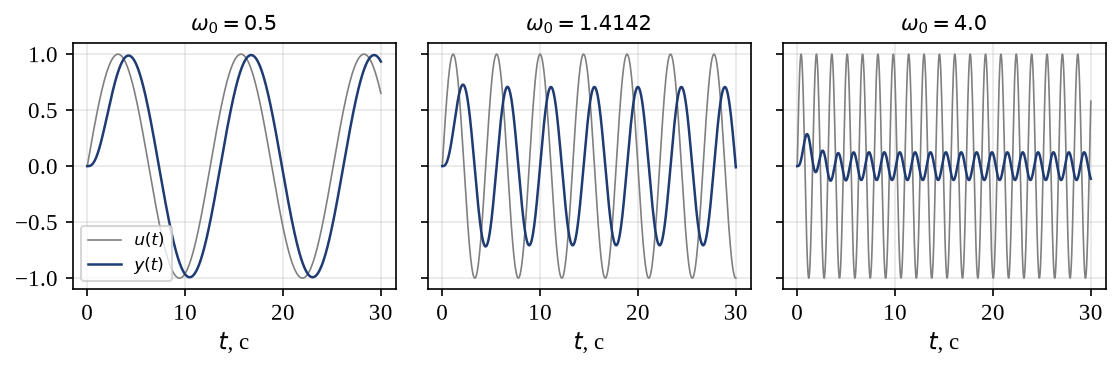

In [9]:
def measure_response(w0: float, t_end: float = 120.0, n: int = 400001):
    """-> (виміряні підсилення й фаза, аналітичні підсилення й фаза)."""
    tt = np.linspace(0, t_end, n)
    u = np.sin(w0 * tt)
    _, y, _ = signal.lsim(SYS, U=u, T=tt)
    # Вікно усталеного режиму бере ціле число періодів у другій половині
    # інтервалу: нецілий залишок періоду вносить систематичну похибку в
    # проєкції на sin/cos (для w0=0.5 це давало 1.5568° замість <2° margin).
    period = 2 * np.pi / w0
    n_periods = int((t_end / 2) // period)   # цілі періоди у другій половині інтервалу
    tail = tt >= t_end - n_periods * period
    amp = (y[tail].max() - y[tail].min()) / 2
    # фаза — через проєкції на sin/cos (кореляційний метод)
    s, cc = np.sin(w0 * tt[tail]), np.cos(w0 * tt[tail])
    a, b = 2 * np.mean(y[tail] * s), 2 * np.mean(y[tail] * cc)
    phase = float(np.arctan2(b, a))
    hw = np.polyval(W_NUM, 1j * w0) / np.polyval(W_DEN, 1j * w0)
    return amp, phase, float(abs(hw)), float(np.angle(hw))


fig, axes = plt.subplots(1, 3, figsize=(7.6, 2.6), sharey=True)
for ax, w0 in zip(axes, [0.5, 1.4142, 4.0]):
    amp, ph, amp_t, ph_t = measure_response(w0)
    record("Гармонічний відгук", f"|W| при w={w0} — вимір", f"{amp:.4f}")
    record("Гармонічний відгук", f"|W| при w={w0} — теорія", f"{amp_t:.4f}")
    record("Гармонічний відгук", f"arg W при w={w0} — вимір, град", f"{np.degrees(ph):.2f}")
    record("Гармонічний відгук", f"arg W при w={w0} — теорія, град", f"{np.degrees(ph_t):.2f}")
    assert abs(amp - amp_t) < 0.02, (w0, amp, amp_t)
    assert abs(np.degrees(ph - ph_t)) < 2.0, (w0, ph, ph_t)

    tt = np.linspace(0, 30, 6000)
    u = np.sin(w0 * tt)
    _, y, _ = signal.lsim(SYS, U=u, T=tt)
    ax.plot(tt, u, lw=0.8, color="gray", label="$u(t)$")
    ax.plot(tt, y, lw=1.2, color="#1f3b73", label="$y(t)$")
    ax.set_title(rf"$\omega_0 = {w0}$", fontsize=10)
    ax.set_xlabel("$t$, с")
axes[0].legend(fontsize=8)
fig.tight_layout(); save(fig, "04-harmonic-response.png")

## 6. Частотні характеристики

### Годограф Найквіста

Критерій Найквіста формулюється над **розімкненою** ланкою $L(s)$, а не
над замкненою $W(s)$. Це не деталь оформлення: як буде показано нижче,
замкнена АФЧХ $W(i\omega)$ обмежена одиничним колом ($|W(i\omega)|
\leq 1$ для всіх $\omega$), тож вона фізично не може дійти до точки
$(-1, 0)$ — "не охоплює" для такої кривої істинне за будь-якої системи
і нічого не доводить.

Розімкнена ланка схеми Рис.5 (розділ 5) при обраному $k_u = 4$:

$$L(s) = k_u \cdot \frac{0.5}{s(s+2)} = \frac{2}{s(s+2)}$$

Критерій: якщо $L(s)$ має $P$ полюсів у правій півплощині, а її
годограф охоплює точку $(-1,0)$ рівно $N$ разів, то число полюсів
замкненої системи в правій півплощині $Z = N + P$; замкнена система
стійка тоді й лише тоді, коли $Z = 0$. Єдиний полюс $L(s)$ у нулі лежить
на уявній осі, а не в лівій чи правій півплощині, — за стандартом його
обходять малим півколом праворуч від початку координат, і в підрахунок
$P$ (полюсів у **відкритій** правій півплощині) він не входить.

Найквіст (розімкнена L(s)) | L(s) = ku*0.5/(s(s+2)) = 2/(s(s+2))  
Найквіст (розімкнена L(s)) | min Re L(iw) = -0.5000  -> -0.5 при w->0, ніколи менше
Найквіст (розімкнена L(s)) | найближча відстань годографа до (-1,0) = 0.7862  
Найквіст (розімкнена L(s)) | розімкнений годограф охоплює точку (-1,0) = False  N=0 обхватів
Найквіст (розімкнена L(s)) | полюсів L(s) у відкритій правій півплощині, P = 0  
Найквіст (розімкнена L(s)) | Z = N + P = 0  0 -> усі полюси замкненої системи в лівій півплощині
Найквіст (розімкнена L(s)) | запас за підсиленням = нескінченний  Re L(iw) > -0.5 > -1 для всіх w>0 -> локус ніколи не перетне промінь (-inf,-1]


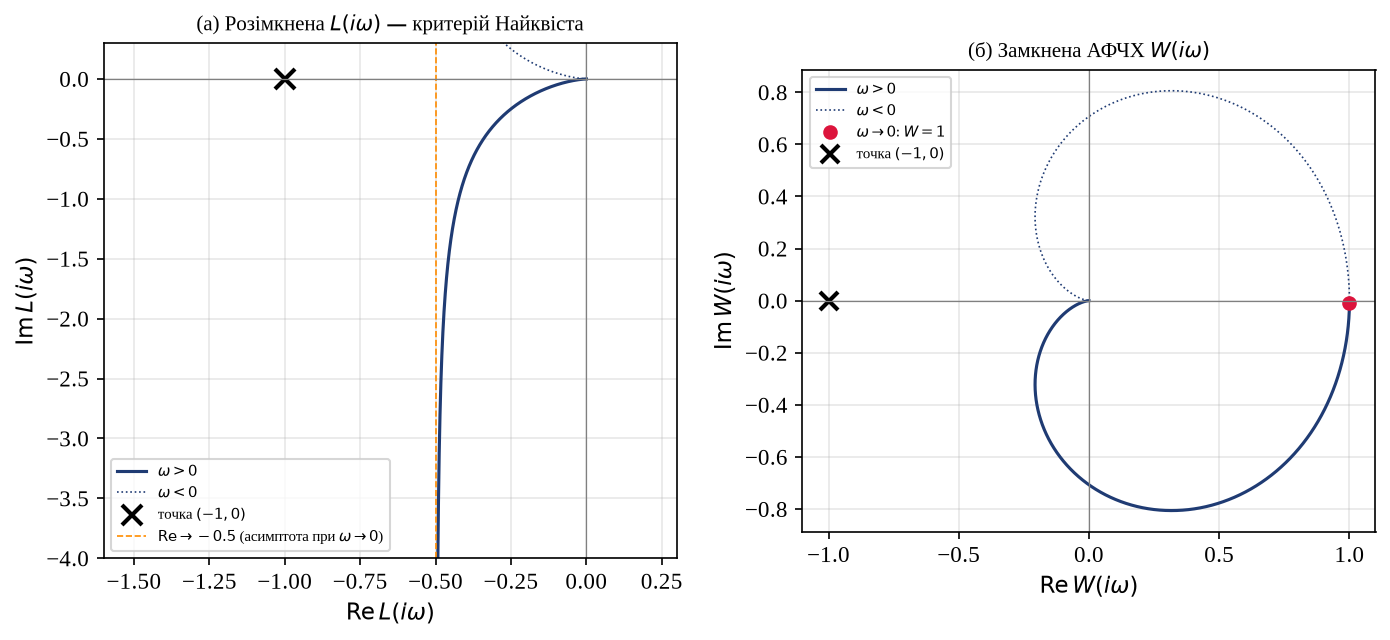

Найквіст (замкнена W(s)) | W(i0) = 0.9999  
Найквіст (замкнена W(s)) | max |W(iw)| = 1.0000  <=1 для всіх w -> крива не може дійти до (-1,0), критерій тут незастосовний


In [10]:
L_NUM = [KU * 0.5]
L_DEN = [1.0, 2.0, 0.0]          # s(s+2) = s^2 + 2s
SYS_OPEN = signal.TransferFunction(L_NUM, L_DEN)

w_ol = np.logspace(-4, 3, 20001)   # густо аж до w -> 0, де Re L -> -0.5
_, L = signal.freqresp(SYS_OPEN, w_ol)

w = np.logspace(-2, 2, 20001)
_, H = signal.freqresp(SYS, w)

re_min = float(L.real.min())
dist_to_m1 = np.abs(L - (-1 + 0j))
closest = float(dist_to_m1.min())
open_loop_poles = np.roots(L_DEN)
P = int((open_loop_poles.real > 0).sum())   # полюсів у ВІДКРИТІЙ правій півплощині
N = 0                                       # крива у 3-й чверті, Re > -1 всюди -> обхватів немає
Z = N + P

record("Найквіст (розімкнена L(s))", "L(s) = ku*0.5/(s(s+2))", "2/(s(s+2))")
record("Найквіст (розімкнена L(s))", "min Re L(iw)", f"{re_min:.4f}",
       "-> -0.5 при w->0, ніколи менше")
record("Найквіст (розімкнена L(s))", "найближча відстань годографа до (-1,0)",
       f"{closest:.4f}")
record("Найквіст (розімкнена L(s))", "розімкнений годограф охоплює точку (-1,0)", False,
       f"N={N} обхватів")
record("Найквіст (розімкнена L(s))", "полюсів L(s) у відкритій правій півплощині, P", P)
record("Найквіст (розімкнена L(s))", "Z = N + P", Z,
       "0 -> усі полюси замкненої системи в лівій півплощині")
record("Найквіст (розімкнена L(s))", "запас за підсиленням", "нескінченний",
       "Re L(iw) > -0.5 > -1 для всіх w>0 -> локус ніколи не перетне промінь (-inf,-1]")

assert re_min > -0.5
assert abs(re_min - (-0.5)) < 1e-3
assert abs(closest - 0.7862) < 1e-3
assert (L.real < 0).all() and (L.imag < 0).all(), "локус має лишатись у 3-й чверті при w>0"
assert (L.real > -1).all(), "локус не повинен перетинати промінь Re<=-1 (запас за підсиленням)"
assert P == 0
assert N == 0
assert Z == 0

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.4))

ax = axes[0]
ax.plot(L.real, L.imag, color="#1f3b73", label=r"$\omega > 0$")
ax.plot(L.real, -L.imag, color="#1f3b73", ls=":", lw=0.8, label=r"$\omega < 0$")
ax.plot([-1], [0], "x", ms=10, mew=2, color="black", label="точка $(-1, 0)$")
ax.axvline(-0.5, color="darkorange", lw=0.8, ls="--",
           label=r"$\mathrm{Re} \to -0.5$ (асимптота при $\omega \to 0$)")
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_xlim(-1.6, 0.3)
ax.set_ylim(-4, 0.3)   # хвіст Im -> -inf при w->0 обрізано; крива продовжується вниз
ax.set_xlabel(r"$\mathrm{Re}\,L(i\omega)$"); ax.set_ylabel(r"$\mathrm{Im}\,L(i\omega)$")
ax.set_title("(а) Розімкнена $L(i\\omega)$ — критерій Найквіста", fontsize=10)
ax.legend(fontsize=7, loc="lower left")

ax = axes[1]
ax.plot(H.real, H.imag, color="#1f3b73", label=r"$\omega > 0$")
ax.plot(H.real, -H.imag, color="#1f3b73", ls=":", lw=0.8, label=r"$\omega < 0$")
ax.plot([H.real[0]], [H.imag[0]], "o", ms=6, color="crimson",
        label=r"$\omega \to 0$: $W = 1$")
ax.plot([-1], [0], "x", ms=9, mew=2, color="black", label="точка $(-1, 0)$")
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel(r"$\mathrm{Re}\,W(i\omega)$"); ax.set_ylabel(r"$\mathrm{Im}\,W(i\omega)$")
ax.set_title("(б) Замкнена АФЧХ $W(i\\omega)$", fontsize=10)
ax.set_aspect("equal"); ax.legend(fontsize=7)

fig.tight_layout(); save(fig, "05-nyquist.png")

record("Найквіст (замкнена W(s))", "W(i0)", f"{H[0].real:.4f}")
record("Найквіст (замкнена W(s))", "max |W(iw)|", f"{np.abs(H).max():.4f}",
       "<=1 для всіх w -> крива не може дійти до (-1,0), критерій тут незастосовний")

**Панель (а), розімкнена $L(i\omega)$.** При $\omega > 0$ годограф
лежить цілком у третій чверті ($\mathrm{Re}\,L < 0$, $\mathrm{Im}\,L <
0$): йде від $(-0.5, -\infty)$ при $\omega \to 0^+$ (на рисунку хвіст
обрізано лінією $\mathrm{Im}=-4$, крива продовжується вниз) до початку
координат при $\omega \to \infty$, наближаючись до нього вздовж напряму
$-180°$. Найближче до точки $(-1, 0)$ крива підходить на відстань
$0.7862$ — з запасом, а не впритул. Полюсів $L(s)$ у відкритій правій
півплощині немає ($P=0$; полюс у нулі — на уявній осі, обходиться
індентацією), обхватів точки $(-1,0)$ теж немає ($N=0$), тож
$Z = N + P = 0$: **замкнена система стійка**. Це узгоджується з розділом
5, де стійкість уже встановлено прямим обчисленням полюсів ($-1 \pm i$,
обидва в лівій півплощині) — два незалежні аргументи, що дають той самий
висновок.

Змістовний результат: оскільки $\mathrm{Re}\,L(i\omega) \geq -0.5$ для
всіх $\omega$, крива ніколи не перетинає промінь $(-\infty, -1]$
дійсної осі — **запас за підсиленням нескінченний**. Це пояснює, чому
в розділі 5 значення $k_u=4$ довелося підбирати не з міркувань
стійкості (вона гарантована за будь-якого $k_u>0$ — детальніше в
`notes.md`), а виключно з бажання отримати $\zeta=1/\sqrt2$: межі
стійкості за підсиленням для цієї схеми просто не існує.

**Панель (б), замкнена $W(i\omega)$.** Це легітимна частотна
характеристика (АФЧХ замкненої системи), яку варто побудувати й
розглянути — але не як доказ стійкості: крива починається в $(1, 0)$
при $\omega \to 0$ (бо $W(0)=1$) і спіраллю стягується в початок
координат при $\omega \to \infty$, повністю в межах кола $|W| \leq 1$
($\max|W(i\omega)| = 1.0000$, на панелі (б) видно, що крива ніде не
виходить за одиничне коло). Саме тому вона й не може підійти до
$(-1, 0)$ за жодних умов — цей факт про будь-яку систему з $|W|\leq 1$,
а не про стійкість саме цієї.

### АЧХ і ФЧХ

Максимум АЧХ $M_p$ досягається на резонансній частоті $\omega_r$. Для ланки
II порядку резонанс існує лише при $\zeta < 1/\sqrt{2} \approx 0.707$, причому
$\omega_r = \omega_n\sqrt{1 - 2\zeta^2}$. У нас $\zeta$ дорівнює цій межі **точно**,
тож резонансного піка немає — АЧХ монотонно спадає.

АЧХ | max |W(iw)| = 1.0000  
АЧХ | |W(i0)| = 1.0000  
АЧХ | резонансний пік є = False  zeta = 0.7071 — точно межа 1/sqrt(2)
АЧХ | смуга пропускання B (-3 дБ), рад/с = 1.4125  
АЧХ | zeta межі резонансу = 0.7071  


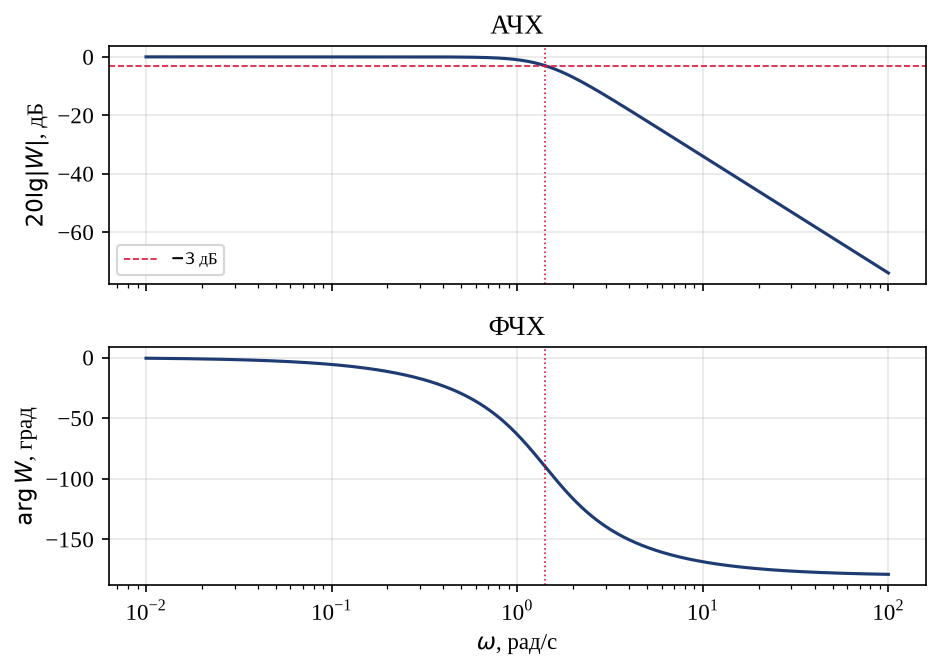

In [11]:
mag = np.abs(H)
peak_idx = int(np.argmax(mag))
has_resonance = bool(mag.max() > mag[0] * 1.0001)
db = 20 * np.log10(mag)
BANDWIDTH = float(w[np.where(db <= db[0] - 3)[0][0]])

record("АЧХ", "max |W(iw)|", f"{mag.max():.4f}")
record("АЧХ", "|W(i0)|", f"{mag[0]:.4f}")
record("АЧХ", "резонансний пік є", has_resonance,
       "zeta = 0.7071 — точно межа 1/sqrt(2)")
record("АЧХ", "смуга пропускання B (-3 дБ), рад/с", f"{BANDWIDTH:.4f}")
record("АЧХ", "zeta межі резонансу", f"{1 / np.sqrt(2):.4f}")

assert not has_resonance
assert abs(BANDWIDTH - 1.4125) < 0.05

w_b, mag_db, phase_deg = signal.bode(SYS, w=w)
fig, axes = plt.subplots(2, 1, figsize=(6.4, 4.6), sharex=True)
axes[0].semilogx(w_b, mag_db, color="#1f3b73")
axes[0].axhline(mag_db[0] - 3, color="crimson", lw=0.8, ls="--", label="$-3$ дБ")
axes[0].axvline(BANDWIDTH, color="crimson", lw=0.8, ls=":")
axes[0].set_ylabel("$20\\lg|W|$, дБ"); axes[0].set_title("АЧХ"); axes[0].legend(fontsize=8)
axes[1].semilogx(w_b, phase_deg, color="#1f3b73")
axes[1].axvline(BANDWIDTH, color="crimson", lw=0.8, ls=":")
axes[1].set_ylabel(r"$\arg W$, град"); axes[1].set_xlabel(r"$\omega$, рад/с")
axes[1].set_title("ФЧХ")
fig.tight_layout(); save(fig, "06-bode.png")

Максимум АЧХ дорівнює значенню при $\omega = 0$: пік відсутній не випадково
— це пряме наслідок того, що $\zeta = 0.7071$ лежить **рівно** на межі
$1/\sqrt2$, при якій формула $\omega_r = \omega_n\sqrt{1 - 2\zeta^2}$
обертається в нуль. Трохи менше $\zeta$ — і резонансний пік з'явився б.

Резонанс і стійкість пов'язані змістовно, а не лише формально: пік $M_p$
зростає при $\zeta \to 0$, тобто саме тоді, коли полюси замкненої системи
наближаються до уявної осі (межі стійкості). Резонансний пік на АЧХ — це
частотний "відбиток" цього наближення: чим ближче полюси до уявної осі,
тим вищий і гостріший пік. У нас полюси $-1 \pm i$ мають помітну від'ємну
дійсну частину — далеко від межі, тому й піка немає.

Смуга пропускання $B \approx 1.4125$ рад/с $\approx \omega_n$ — це частота,
на якій підсилення падає на 3 дБ від статичного значення $|W(0)| = 1$. Вона
і є межею "замкнення" системи: гармонічні складові входу з $\omega > B$
система суттєво послаблює й не встигає їх відтворити, тоді як складові з
$\omega < B$ проходять майже без ослаблення. На високих частотах АЧХ спадає
з нахилом $-40$ дБ/дек (двічі диференціювальна ланка II порядку), а ФЧХ
прямує до $-180^\circ$.

### Чи є зв'язок між АЧХ і ФЧХ?

Так. $W(s) = 2/(s^2+2s+2)$ не має нулів і має обидва полюси в лівій півплощині,
тобто є **мінімально-фазовою**. Для таких систем фаза однозначно відновлюється
з ходу АЧХ (співвідношення Боде): нахилу $-20n$ дБ/дек відповідає фаза
$\approx -90^\circ n$. Перевіряємо чисельно на високих частотах.

In [12]:
hi = w_b > 30
slope = float(np.polyfit(np.log10(w_b[hi]), mag_db[hi], 1)[0])
record("Зв'язок АЧХ-ФЧХ", "нахил АЧХ на високих частотах, дБ/дек", f"{slope:.2f}",
       "очікується -40 для ланки II порядку")
record("Зв'язок АЧХ-ФЧХ", "фаза на високих частотах, град", f"{phase_deg[-1]:.2f}",
       "очікується -180")
assert abs(slope + 40) < 1.0
assert abs(phase_deg[-1] + 180) < 2.0

Зв'язок АЧХ-ФЧХ | нахил АЧХ на високих частотах, дБ/дек = -40.00  очікується -40 для ланки II порядку
Зв'язок АЧХ-ФЧХ | фаза на високих частотах, град = -178.85  очікується -180


Нахил $-40$ дБ/дек ($n = 2$) і фаза $-180^\circ$ ($-90^\circ \cdot 2$) —
рівно те, що передбачає співвідношення Боде для мінімально-фазової ланки.
Це не два незалежні спостереження, а одне: маючи лише хід АЧХ мінімально-
фазової системи, ФЧХ можна відновити без окремого вимірювання фази — саме
в цьому й полягає зв'язок між АЧХ і ФЧХ.

## 7. Диференціальне рівняння

$W(s) = \dfrac{2}{s^2 + 2s + 2}$ відповідає рівнянню
$\ddot y + 2\dot y + 2y = 2u$ при нульових початкових умовах.
Розв'язуємо його чисельно і накладаємо на відгук `signal.lsim` —
нев'язка має бути на рівні похибки інтегрування.

ДР vs ПФ | макс. нев'язка розв'язку ДР і lsim = 3.03e-06  на рівні похибки інтегрування -> моделі тотожні


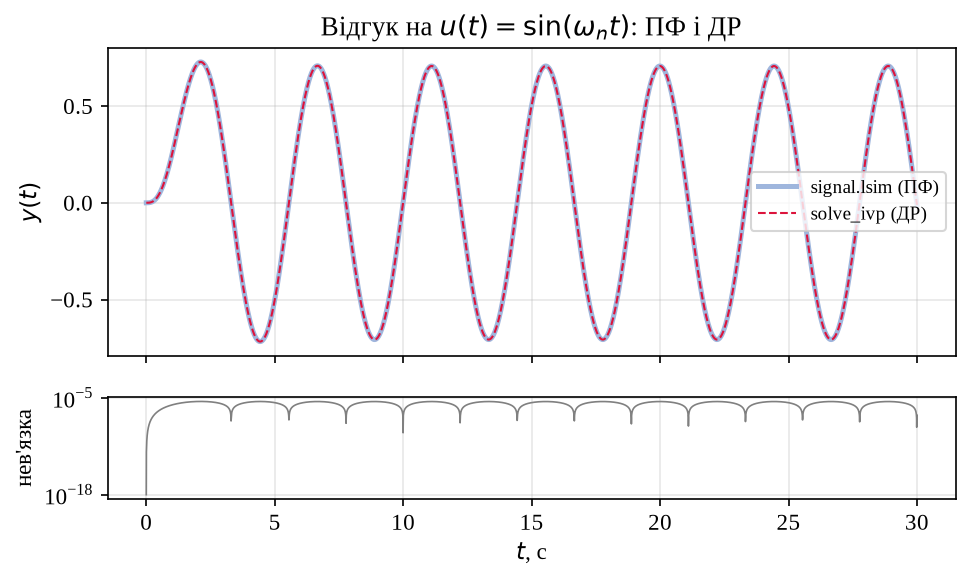

In [13]:
from scipy.integrate import solve_ivp

def rhs(tt, state, u_of_t):
    y, dy = state
    return [dy, -2 * dy - 2 * y + 2 * u_of_t(tt)]


t_ode = np.linspace(0, 30, 6000)
u_fn = lambda tt: np.sin(1.4142 * tt)
sol = solve_ivp(rhs, (t_ode[0], t_ode[-1]), [0.0, 0.0], t_eval=t_ode,
                args=(u_fn,), rtol=1e-10, atol=1e-12)
_, y_lsim, _ = signal.lsim(SYS, U=u_fn(t_ode), T=t_ode)

resid = float(np.abs(sol.y[0] - y_lsim).max())
record("ДР vs ПФ", "макс. нев'язка розв'язку ДР і lsim", f"{resid:.2e}",
       "на рівні похибки інтегрування -> моделі тотожні")
assert resid < 1e-4, resid

fig, axes = plt.subplots(2, 1, figsize=(6.6, 4.0), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(t_ode, y_lsim, lw=2.4, color="#9fb6dd", label="signal.lsim (ПФ)")
axes[0].plot(t_ode, sol.y[0], lw=1.0, color="crimson", ls="--", label="solve_ivp (ДР)")
axes[0].set_ylabel("$y(t)$"); axes[0].legend(fontsize=9)
axes[0].set_title(r"Відгук на $u(t) = \sin(\omega_n t)$: ПФ і ДР")
axes[1].semilogy(t_ode, np.abs(sol.y[0] - y_lsim) + 1e-18, lw=0.8, color="gray")
axes[1].set_ylabel("нев'язка"); axes[1].set_xlabel("$t$, с")
fig.tight_layout(); save(fig, "07-ode-vs-lsim.png")

## 8. Задача реалізації — канонічні форми

**КФК** (канонічна форма керованості) і **КФС** (канонічна форма спостережуваності)
для $W(s) = \dfrac{2}{s^2 + 2s + 2}$. КФС — транспонована пара до КФК:
$A_o = A_c^{T}$, $B_o = C_c^{T}$, $C_o = B_c^{T}$.

Канонічні форми | КФК: C(sI-A)^-1 B + D = 2.0/(1.0*s**2 + 2.0*s + 2.0)  
Канонічні форми | КФС: C(sI-A)^-1 B + D = 2.0/(1.0*s**2 + 2.0*s + 2.0)  
Канонічні форми | ранг матриці керованості КФК = 2  
Канонічні форми | ранг матриці спостережуваності КФС = 2  
Канонічні форми | макс. нев'язка ПФ vs КФК = 4.44e-16  
Канонічні форми | макс. нев'язка ПФ vs КФС = 2.66e-15  


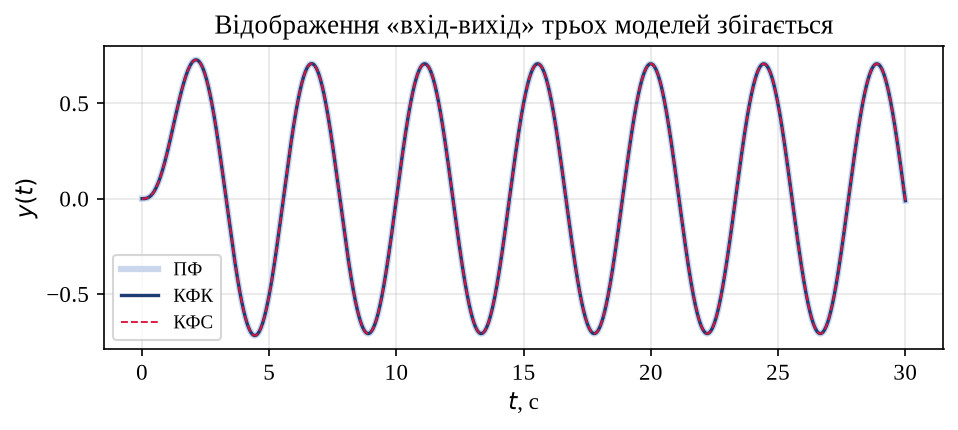

In [14]:
import sympy as sp

A_c = np.array([[0.0, 1.0], [-2.0, -2.0]])
B_c = np.array([[0.0], [1.0]])
C_c = np.array([[2.0, 0.0]])
D_c = np.array([[0.0]])

A_o, B_o, C_o, D_o = A_c.T, C_c.T, B_c.T, D_c

s = sp.symbols("s")


def symbolic_tf(A, B, C, D):
    """C(sI - A)^{-1} B + D у символьному вигляді."""
    A, B, C, D = map(sp.Matrix, (A, B, C, D))
    expr = (C * (s * sp.eye(A.shape[0]) - A).inv() * B + D)[0, 0]
    return sp.simplify(sp.together(expr))


tf_c, tf_o = symbolic_tf(A_c, B_c, C_c, D_c), symbolic_tf(A_o, B_o, C_o, D_o)
tf_ref = sp.simplify(sp.Rational(2) / (s**2 + 2 * s + 2))

record("Канонічні форми", "КФК: C(sI-A)^-1 B + D", str(tf_c))
record("Канонічні форми", "КФС: C(sI-A)^-1 B + D", str(tf_o))
assert sp.simplify(tf_c - tf_ref) == 0
assert sp.simplify(tf_o - tf_ref) == 0

ctrb = np.hstack([B_c, A_c @ B_c])
obsv = np.vstack([C_o, C_o @ A_o])
record("Канонічні форми", "ранг матриці керованості КФК", int(np.linalg.matrix_rank(ctrb)))
record("Канонічні форми", "ранг матриці спостережуваності КФС", int(np.linalg.matrix_rank(obsv)))
assert np.linalg.matrix_rank(ctrb) == 2
assert np.linalg.matrix_rank(obsv) == 2

# три моделі -> один вхід -> три криві, що збігаються
u = np.sin(1.4142 * t_ode)
_, y_tf, _ = signal.lsim(SYS, U=u, T=t_ode)
_, y_kfk, _ = signal.lsim(signal.StateSpace(A_c, B_c, C_c, D_c), U=u, T=t_ode)
_, y_kfs, _ = signal.lsim(signal.StateSpace(A_o, B_o, C_o, D_o), U=u, T=t_ode)

record("Канонічні форми", "макс. нев'язка ПФ vs КФК", f"{np.abs(y_tf - y_kfk).max():.2e}")
record("Канонічні форми", "макс. нев'язка ПФ vs КФС", f"{np.abs(y_tf - y_kfs).max():.2e}")
assert np.abs(y_tf - y_kfk).max() < 1e-8
assert np.abs(y_tf - y_kfs).max() < 1e-8

fig, ax = plt.subplots(figsize=(6.6, 3.0))
ax.plot(t_ode, y_tf, lw=3.0, color="#c9d6ec", label="ПФ")
ax.plot(t_ode, y_kfk, lw=1.6, color="#1f3b73", label="КФК")
ax.plot(t_ode, y_kfs, lw=0.9, color="crimson", ls="--", label="КФС")
ax.set_xlabel("$t$, с"); ax.set_ylabel("$y(t)$")
ax.set_title("Відображення «вхід-вихід» трьох моделей збігається")
ax.legend(fontsize=9)
fig.tight_layout(); save(fig, "08-canonical-forms.png")

## 9. Додаток: власну $G(p)$ все ж можна застабілізувати

Доведена вище нестабілізовність (розділ 2) стосується **пропорційного
виходового** зворотного зв'язку, а не системи взагалі — це різні твердження,
і плутати їх не можна. Пара $(A, B)$ для $G(p)$ керована (ранг матриці
керованості = 4 з 4), тож зворотний зв'язок **за станом** $u = -Kx + v$
розміщує полюси де завгодно, зокрема в лівій півплощині. Тобто система не
є «нестабілізовною» — вона лише не стабілізовна саме пропорційним виходовим
зворотним зв'язком. Це прямо продовжує тему канонічних форм.

Стабілізація за станом | ранг матриці керованості G(p) = 4  з 4
Стабілізація за станом | бажані полюси = [(-2+0j), (-1-1j), (-1+0j), (-1+1j)]  
Стабілізація за станом | отримані полюси = [(-2+0j), (-1-1j), (-1+1j), (-1+0j)]  
Стабілізація за станом | матриця K = [[5.0, 10.0, 9.5455, 3.9091]]  


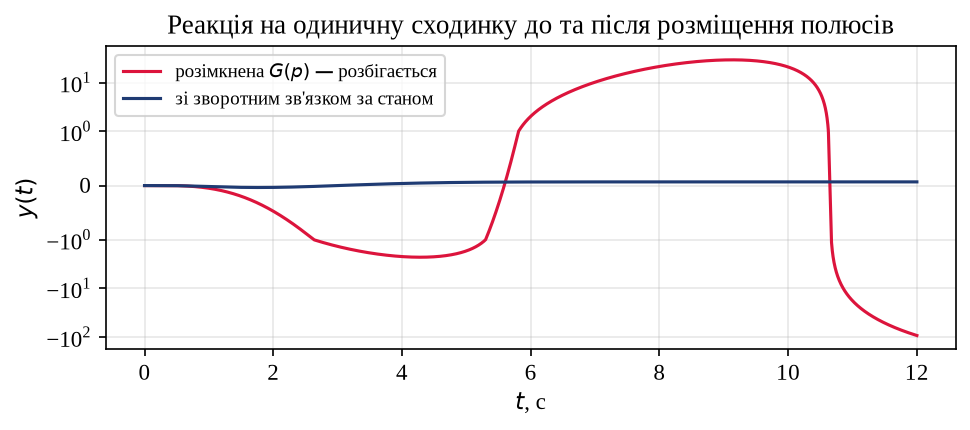

In [15]:
A, B, C, D = signal.tf2ss(NUM, DEN)
ctrb_g = np.hstack([np.linalg.matrix_power(A, k) @ B for k in range(A.shape[0])])
record("Стабілізація за станом", "ранг матриці керованості G(p)",
       int(np.linalg.matrix_rank(ctrb_g)), f"з {A.shape[0]}")
assert np.linalg.matrix_rank(ctrb_g) == 4

desired = np.array([-1.0, -2.0, -1 + 1j, -1 - 1j])
K = signal.place_poles(A, B, desired).gain_matrix
placed = np.linalg.eigvals(A - B @ K)
record("Стабілізація за станом", "бажані полюси", np.round(np.sort_complex(desired), 4).tolist())
record("Стабілізація за станом", "отримані полюси", np.round(np.sort_complex(placed), 4).tolist())
record("Стабілізація за станом", "матриця K", np.round(K, 4).tolist())
assert (placed.real < 0).all()

t_sf = np.linspace(0, 12, 4000)
step_in = np.ones_like(t_sf)
_, y_open, _ = signal.lsim(signal.StateSpace(A, B, C, D), U=step_in, T=t_sf)
_, y_closed, _ = signal.lsim(signal.StateSpace(A - B @ K, B, C, D), U=step_in, T=t_sf)

fig, ax = plt.subplots(figsize=(6.6, 3.0))
ax.plot(t_sf, y_open, color="crimson", label="розімкнена $G(p)$ — розбігається")
ax.plot(t_sf, y_closed, color="#1f3b73", label="зі зворотним зв'язком за станом")
ax.set_yscale("symlog", linthresh=1.0)
ax.set_xlabel("$t$, с"); ax.set_ylabel("$y(t)$")
ax.set_title("Реакція на одиничну сходинку до та після розміщення полюсів")
ax.legend(fontsize=9)
fig.tight_layout(); save(fig, "09-state-feedback.png")

## Зведення результатів

Усі числа звіту беруться з цього файла, а не переписуються руками.

In [16]:
import csv

with open(DATA / "results-summary.csv", "w", newline="", encoding="utf-8") as fh:
    writer = csv.DictWriter(fh, fieldnames=["розділ", "показник", "значення", "примітка"])
    writer.writeheader()
    writer.writerows(RESULTS)
print(f"записано {len(RESULTS)} рядків у {DATA / 'results-summary.csv'}")

записано 64 рядків у data/results-summary.csv
